In [1]:
import torch
from ultralytics import YOLO
from attacks import disappearance_dag_attack,targeted_dag_attack, fool_detectors_attack, fgsm_attack_detector, pgd_attack_detector, square_attack_detector, hop_skip_jump_attack
from util import compare_original_and_adversarial, compare_original_and_adversarial_png, sample_images_by_class , preprocess_image


In [15]:
model = YOLO("yolov8n_TrafficSigns.pt")
image_path="../120.jpg"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Disappearance DAG Attack

---

## 1. Attack Idea
This attack is inspired by the **Dense Adversary Generation (DAG)** algorithm. It generates imperceptible perturbations to make object detections "disappear" by suppressing their confidence scores in YOLOv8. Unlike targeted attacks, it does NOT specify new classes for predictions.

---

## 2. Attack Steps & Loss Function

### Key Steps:
1. **Target Selection**: Find all detections with confidence > `conf_threshold`.
2. **Loss Calculation**: Minimize the model's confidence for these detections.
3. **Gradient Update**: Perturb the image iteratively using L-infinity bounded steps.

### Loss Function:
The loss aims to reduce logits (pre-sigmoid scores) of predicted classes:
$$
\text{Loss} = -\sum_{i \in \text{targets}} \text{logit}(c_i)
$$
where:
- $c_i$ = predicted class for detection $i$
- $\text{logit}(c_i)$ = raw output score for class $c_i$

---

## 3. Implementation Summary
```python
def disappearance_dag_attack(...):
    # 1. Load YOLO models (raw + high-level)
    # 2. Preprocess image to tensor
    # 3. For N iterations:
    #    a) Get raw model predictions
    #    b) Select high-confidence detections
    #    c) Compute loss over targets
    #    d) Update image: image += gamma * sign(gradient)
    # 4. Return perturbed image
```

---

## 4. Usage Example
```python
from ultralytics import YOLO

# Generate adversarial image
adv_image = disappearance_dag_attack(
    image_path="test.jpg",
    num_iterations=15,
    gamma=0.05,
    device="cuda"
)

# Compare results
model = YOLO("yolov8n.pt")
model.predict("test.jpg")[0].show()     # Original detections
model.predict(adv_image)[0].show()      # Objects disappear
```
## **paper:**
Adversarial Examples for Semantic Segmentation and Object Detection

In [3]:
adv_image = disappearance_dag_attack(image_path, model_path="yolov8n_TrafficSigns.pt",num_iterations=20, gamma=0.003,conf_threshold=0.25)


0: 640x640 1 Speed Limit 120, 335.6ms
Speed: 0.0ms preprocess, 335.6ms inference, 10.6ms postprocess per image at shape (1, 3, 640, 640)
Iteration 0: #rows_to_attack=249, loss=-9.4710

0: 640x640 1 Speed Limit 120, 413.8ms
Speed: 0.0ms preprocess, 413.8ms inference, 7.7ms postprocess per image at shape (1, 3, 640, 640)
Iteration 1: #rows_to_attack=232, loss=-8.3051

0: 640x640 1 Speed Limit 120, 266.8ms
Speed: 0.0ms preprocess, 266.8ms inference, 5.7ms postprocess per image at shape (1, 3, 640, 640)
Iteration 2: #rows_to_attack=208, loss=-2.8737

0: 640x640 1 Speed Limit 80, 299.6ms
Speed: 0.0ms preprocess, 299.6ms inference, 9.5ms postprocess per image at shape (1, 3, 640, 640)
Iteration 3: #rows_to_attack=571, loss=-6.6171

0: 640x640 1 Speed Limit 80, 893.5ms
Speed: 0.0ms preprocess, 893.5ms inference, 12.0ms postprocess per image at shape (1, 3, 640, 640)
Iteration 4: #rows_to_attack=555, loss=-1.5189

0: 640x640 (no detections), 301.0ms
Speed: 0.0ms preprocess, 301.0ms inference,

Running prediction on original tensor...



0: 640x640 1 Speed Limit 120, 318.0ms
Speed: 0.0ms preprocess, 318.0ms inference, 4.2ms postprocess per image at shape (1, 3, 640, 640)
Running prediction on loaded adversarial tensor...

0: 640x640 (no detections), 511.7ms
Speed: 0.0ms preprocess, 511.7ms inference, 5.8ms postprocess per image at shape (1, 3, 640, 640)


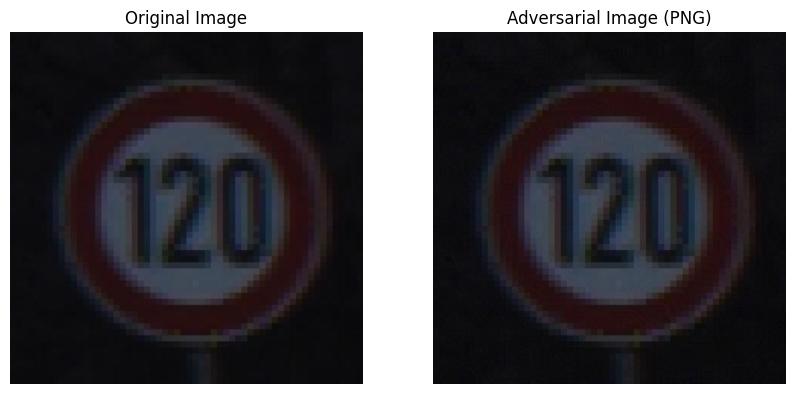

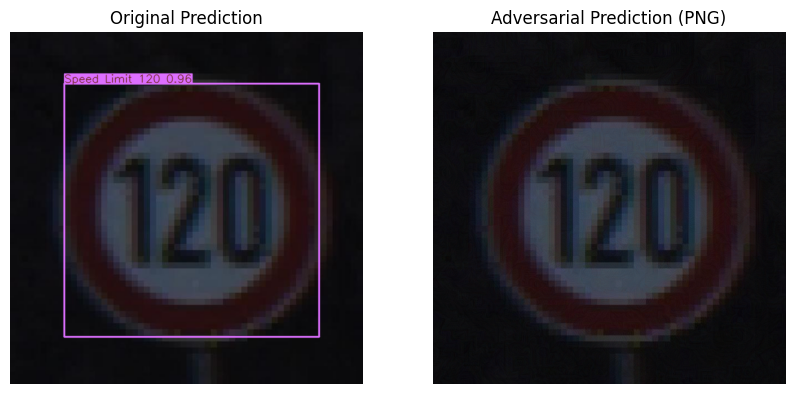

In [4]:
compare_original_and_adversarial_png(model ,image_path,adv_image,0.25)

# Targeted DAG Attack 

---

## 1. Attack Idea
This **targeted attack** modifies the DAG algorithm to push all detections toward a specific adversarial class. It combines:
1. **Suppression** of original high-confidence detections
2. **Promotion** of a chosen adversarial class
3. **Early stopping** when the adversarial class dominates

---

## 2. Attack Steps & Loss Function

### Key Stages:
1. **Initial Analysis**: Identify original high-confidence classes
2. **Targeted Perturbation**:
   - Push original detections toward adversarial class
   - If no originals remain, boost adversarial class globally
3. **Termination**: Stop when adversarial class appears and originals disappear

### Loss Function
The loss has two modes depending on remaining targets:

1. **Targeted Mode** (original detections present):
$$
\text{Loss} = \sum_{i \in \text{targets}} (\text{logit}_{\text{adv}}^{(i)} - \text{logit}_{\text{orig}}^{(i)})
$$
- $\text{logit}_{\text{adv}}$: Adversarial class score
- $\text{logit}_{\text{orig}}$: Original class score

2. **Global Promotion Mode** (no originals left):
$$
\text{Loss} = \sum_{i} \text{logit}_{\text{adv}}^{(i)}
$$

---

## 3. Implementation Summary
```python
def targeted_dag_attack(...):
    # 1. Load YOLO models (raw + high-level)
    # 2. Get original predictions to determine target classes
    # 3. For N iterations:
    #    a) Calculate class logits from raw model
    #    b) Select rows with original classes
    #    c) Compute loss based on current mode
    #    d) Update image: image += gamma * sign(gradient)
    #    e) Check stop condition (adv_class present + targets gone)
    # 4. Return perturbed image and stop status
```

---

## 4. Usage Example
```python
from ultralytics import YOLO

# Convert cat detections to "truck" (class 7)
adv_image, stopped_early = targeted_dag_attack(
    image_path="cat.jpg",
    adversarial_class=7,    # COCO class index for truck
    num_iterations=20,
    gamma=0.04,
    conf_threshold=0.3,
    device="cuda"
)

# Analyze results
model = YOLO("yolov8n.pt")
print("Original classes:", model("cat.jpg")[0].boxes.cls.unique())
print("Adversarial classes:", model(adv_image)[0].boxes.cls.unique())
```
## **paper:**
Adversarial Examples for Semantic Segmentation and Object Detection

In [5]:
adv_image_targeted,success = targeted_dag_attack(
    image_path=image_path,
    model_path="yolov8n_TrafficSigns.pt",
    adversarial_class=0,
    num_iterations=50,
    gamma=0.003,
    conf_threshold=0.25,
    device='cpu')


0: 640x640 1 Speed Limit 120, 302.4ms
Speed: 0.1ms preprocess, 302.4ms inference, 6.3ms postprocess per image at shape (1, 3, 640, 640)
Original classes above conf=0.25: {5}

0: 640x640 1 Speed Limit 120, 288.5ms
Speed: 0.0ms preprocess, 288.5ms inference, 6.8ms postprocess per image at shape (1, 3, 640, 640)
Iteration 0: #rows_to_attack=249, loss=-9.4693

0: 640x640 1 Speed Limit 120, 815.5ms
Speed: 0.0ms preprocess, 815.5ms inference, 7.2ms postprocess per image at shape (1, 3, 640, 640)
Iteration 1: #rows_to_attack=231, loss=-8.3030

0: 640x640 1 Speed Limit 80, 323.1ms
Speed: 0.0ms preprocess, 323.1ms inference, 8.3ms postprocess per image at shape (1, 3, 640, 640)
Iteration 2: #rows_to_attack=212, loss=-2.8322

0: 640x640 1 Green Light, 1 Speed Limit 80, 290.3ms
Speed: 0.0ms preprocess, 290.3ms inference, 10.1ms postprocess per image at shape (1, 3, 640, 640)
Iteration 3: Stop condition met! adversarial_class=0 present, target_classes={5} gone.

0: 640x640 1 Green Light, 1 Speed 

Running prediction on original tensor...

0: 640x640 1 Speed Limit 120, 349.0ms
Speed: 0.0ms preprocess, 349.0ms inference, 7.2ms postprocess per image at shape (1, 3, 640, 640)
Running prediction on loaded adversarial tensor...

0: 640x640 1 Green Light, 1 Speed Limit 80, 428.1ms
Speed: 0.0ms preprocess, 428.1ms inference, 8.3ms postprocess per image at shape (1, 3, 640, 640)


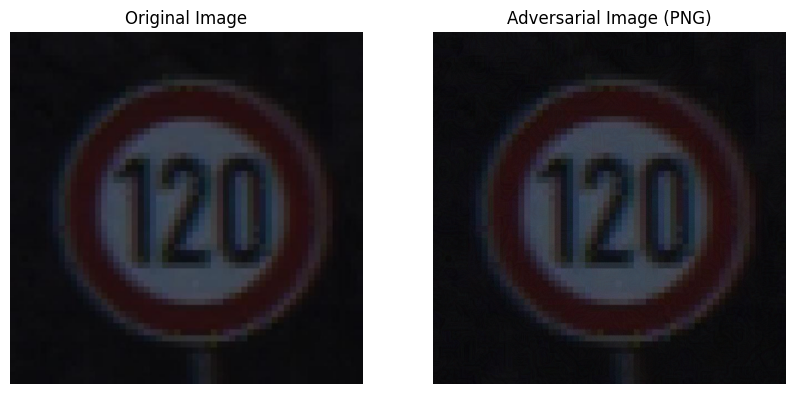

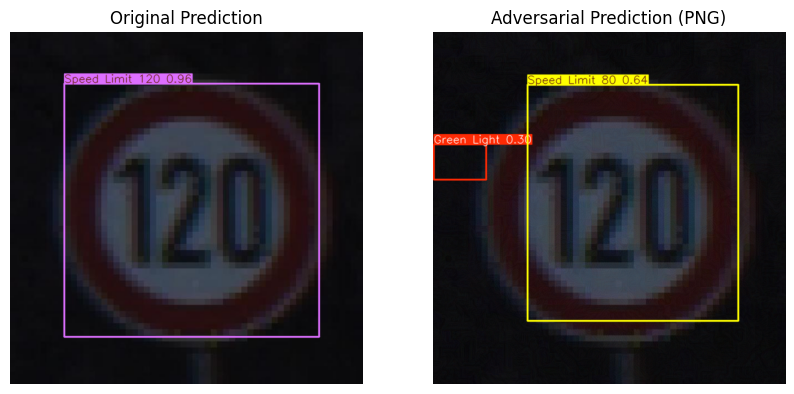

In [6]:
compare_original_and_adversarial_png(model ,image_path,adv_image_targeted ,0.25)

# Fool Detectors Attack 

---

## 1. Attack Idea
This attack implements a **targeted adversarial attack** on object detectors (YOLOv8) inspired by the paper ["Adversarial Examples that Fool Detectors"](#). It generates perturbations to:
1. **Suppress target classes**: Reduce detection confidence for specified COCO classes (e.g., stop signs)
2. **Maintain stealth**: Use L2 regularization to keep adversarial images visually similar to originals
3. **Enable early stopping**: Terminate if target classes are no longer detected

---

## 2. Attack Steps & Loss Function

### Key Components from the Paper:
1. **Detector Vulnerability**: Exploits the detector's sensitivity to gradient patterns in class logits
2. **Multi-Objective Optimization**:
   - Minimize mean confidence of target classes
   - Constrain perturbations to stay near original image (L2 penalty)

### Mathematical Formulation
**Total Loss**:
$$
\text{Loss} = \underbrace{\frac{1}{N}\sum_{i=1}^{N} \text{conf}(c_{\text{target}}^{(i)}}_{\text{Detection Loss}} + \underbrace{\lambda \cdot ||\mathbf{X}_{\text{adv}} - \mathbf{X}_{\text{orig}}||_2^2}_{\text{L2 Regularization}}
$$

Where:
- $c_{\text{target}}$: Target class(es) to suppress
- $\lambda$: Regularization strength (`lambda_reg`)
- $N$: Number of bounding box proposals

---

## 3. Implementation Overview

```python
def fool_detectors_attack(...):
    # 1. Load YOLO models (raw model for gradients, high-level for detection)
    # 2. Preprocess image to tensor [1, 3, H, W]
    # 3. For N iterations:
    #    a) Compute class confidences for target classes
    #    b) Calculate detection loss + L2 penalty
    #    c) Backpropagate gradients
    #    d) Update image: X = X - γ * sign(∇Loss)
    #    e) Early stop if target classes disappear
    # 4. Return adversarial image
```

### Key Components:
| Component               | Description                                                                 |
|-------------------------|-----------------------------------------------------------------------------|
| **Raw Model**           | YOLO backbone without post-processing for gradient computation             |
| **High-Level Model**    | Full YOLO with NMS to check detection results                               |
| **L-inf Update**        | `image -= gamma * grad.sign()` ensures bounded perturbations               |
| **Early Stopping**      | Monitors high-level model predictions for target class disappearance        |

---

## 4. Usage Example

```python
from ultralytics import YOLO
import torch

# Initialize attack (targeting stop signs - COCO class 11)
adv_image = fool_detectors_attack(
    image_path="stop_sign.jpg",
    target_classes=[11],          # COCO class 11 = stop sign
    num_iterations=20,
    gamma=0.05,
    lambda_reg=0.1,               # Balance stealth vs effectiveness
    conf_threshold=0.3,
    device="cuda"
)

# Compare results
model = YOLO("yolov8n.pt")

# Original image
orig_results = model("stop_sign.jpg")[0]
print("Original detections:", orig_results.boxes.cls.tolist())  # e.g., [11, 11]

# Adversarial image 
adv_results = model(adv_image)[0]
print("Adversarial detections:", adv_results.boxes.cls.tolist())  # e.g., []
```
## **paper:**
Adversarial Examples that Fool Detectors

In [8]:
# Run the attack
adv_image = fool_detectors_attack(
    image_path=image_path,
    model_path="yolov8n_TrafficSigns.pt",
    num_iterations=20,
    gamma=0.01,
    conf_threshold=0.25,
    lambda_reg=0.01,
    target_classes = [5],
    device='cpu'
)


0: 640x640 1 Speed Limit 120, 748.8ms
Speed: 0.0ms preprocess, 748.8ms inference, 7.3ms postprocess per image at shape (1, 3, 640, 640)
Iteration 0: Loss_det=0.5003, Loss_L2=0.0000, Total_loss=0.5003

0: 640x640 1 Speed Limit 120, 309.6ms
Speed: 0.0ms preprocess, 309.6ms inference, 12.6ms postprocess per image at shape (1, 3, 640, 640)
Iteration 1: Loss_det=0.5002, Loss_L2=0.0000, Total_loss=0.5002

0: 640x640 1 Speed Limit 80, 283.6ms
Speed: 0.0ms preprocess, 283.6ms inference, 6.5ms postprocess per image at shape (1, 3, 640, 640)
Iteration 2: No target objects detected. Early stopping.


Running prediction on original tensor...

0: 640x640 1 Speed Limit 120, 341.5ms
Speed: 0.0ms preprocess, 341.5ms inference, 12.3ms postprocess per image at shape (1, 3, 640, 640)
Running prediction on loaded adversarial tensor...

0: 640x640 1 Speed Limit 80, 308.2ms
Speed: 0.0ms preprocess, 308.2ms inference, 13.2ms postprocess per image at shape (1, 3, 640, 640)


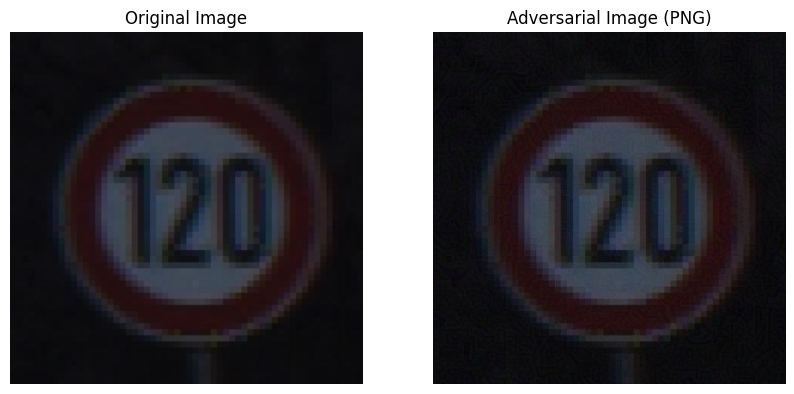

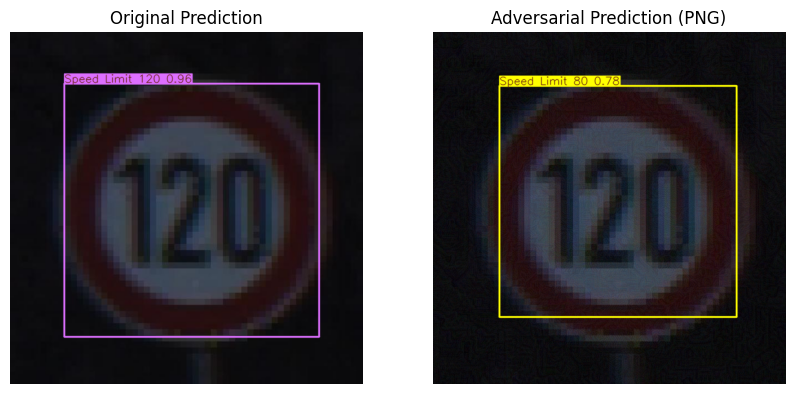

In [9]:
compare_original_and_adversarial_png(model, image_path, adv_image,0.25)

# FGSM Attack for Object Detectors 

---

## 1. Attack Idea
This implementation adapts the **Fast Gradient Sign Method (FGSM)** for object detection models (YOLOv8). The attack:
1. **Targets High-Confidence Detections**: Focuses on predictions with confidence > specified threshold  
2. **Maximizes Classification Error**: Perturbs image to confuse class predictions  
3. **Optional Bounding Box Disruption**: Can simultaneously degrade localization accuracy (disabled by default)  
4. **Maintains Stealth**: Uses L-infinity bounded perturbations (ε typically 0.01-0.1)  
5. **One shot**: not iterative so it is fast and suitable for adversarial training

---

## 2. Attack Steps & Loss Function

### Key Components from FGSM Paper:
1. **Linear Explanation**: Exploits gradient sign direction for efficient perturbation  
2. **Single-Step Attack**: Computes perturbation in one forward/backward pass  

### Mathematical Formulation:
**Total Loss**:
$$
\mathcal{L}_{\text{total}} = \underbrace{-\sum_{i \in \mathcal{D}} \log(p(y_i|\mathbf{x}))}_{\text{Classification Loss}} + \lambda \underbrace{||\mathbf{x}_{\text{adv}} - \mathbf{x}_{\text{orig}}||_2}_{\text{Implicit L2 Constraint}}
$$

Where:
- $\mathcal{D}$ = High-confidence detections  
- $p(y_i|\mathbf{x})$ = Class probability for detection $i$  
- $\lambda$ = Implicitly controlled via ε clamping  

---

## 3. Implementation Overview

### Pipeline:
```python
1. Load YOLOv8 detection model
2. Preprocess input image (normalization + resizing)
3. Extract raw model outputs (bypass NMS/post-processing)
4. Calculate combined confidence scores (objectness × class probability)
5. Filter detections by confidence threshold
6. Compute classification loss between original and current predictions
7. Backpropagate loss to get image gradient
8. Apply perturbation: x_adv = x + ε·sign(∇x ℒ)
9. Clamp to valid pixel range [0,1]
```

### Key Components:
| Component               | Description                                                                 |
|-------------------------|-----------------------------------------------------------------------------|
| **Raw Output Extraction** | Accesses model backbone outputs before non-max suppression                 |
| **Confidence Filtering**  | Combines objectness and class probability for detection quality assessment |
| **Gradient Isolation**    | Only perturbs high-confidence detections via boolean masking              |
| **Device Agnostic**       | Works on both CPU/GPU with automatic tensor placement                      |

---

## 4. Usage Example

```python
from attacks import fgsm_attack_detector
from ultralytics import YOLO

# Generate adversarial example
adv_image = fgsm_attack_detector(
    image_path="highway.jpg",
    model_path="yolov8n.pt",
    epsilon=0.08,        # Moderate perturbation
    conf_threshold=0.6,  # Target confident detections
    device="cuda"
)

# Evaluate attack effectiveness
model = YOLO("yolov8n.pt").to("cuda")
original_results = model("highway.jpg")[0]
adversarial_results = model(adv_image)[0]

print(f"Original detections: {len(original_results.boxes)}")
print(f"Adversarial detections: {len(adversarial_results.boxes)}")
```

## 8. papers

1. **Original FGSM Paper**:  
   [Explaining and Harnessing Adversarial Examples (Goodfellow et al., 2015)](https://arxiv.org/abs/1412.6572)

2. **Object Detector Attacks**:  
   [Adversarial Examples for Object Detectors (Lu et al., 2017)](https://arxiv.org/abs/1712.08063)

3. **YOLOv8 Documentation**:  
   [Ultralytics YOLOv8 Docs](https://docs.ultralytics.com/)


In [20]:
adv_image= fgsm_attack_detector(
    image_path= image_path,
    model = model,
    epsilon=  0.08,
    conf_threshold= 0.25,
    device = 'cpu'
)

Running prediction on original...

0: 640x640 1 Speed Limit 120, 494.5ms
Speed: 0.0ms preprocess, 494.5ms inference, 7.4ms postprocess per image at shape (1, 3, 640, 640)
Running prediction on adversarial...

0: 640x640 (no detections), 346.1ms
Speed: 0.0ms preprocess, 346.1ms inference, 10.0ms postprocess per image at shape (1, 3, 640, 640)


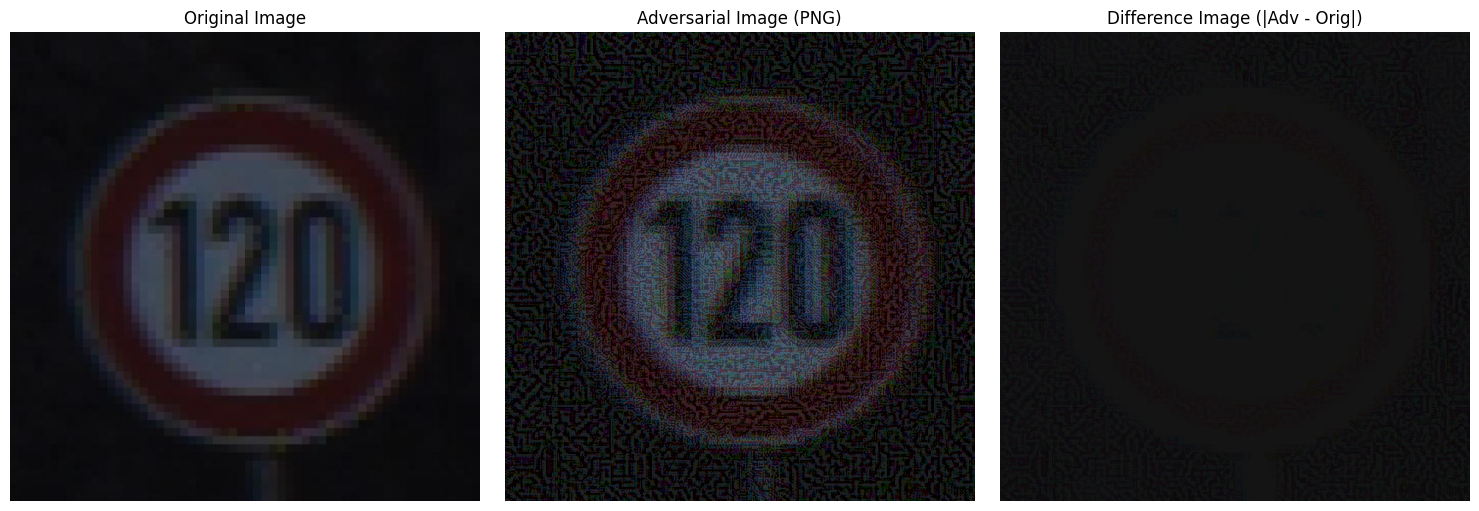

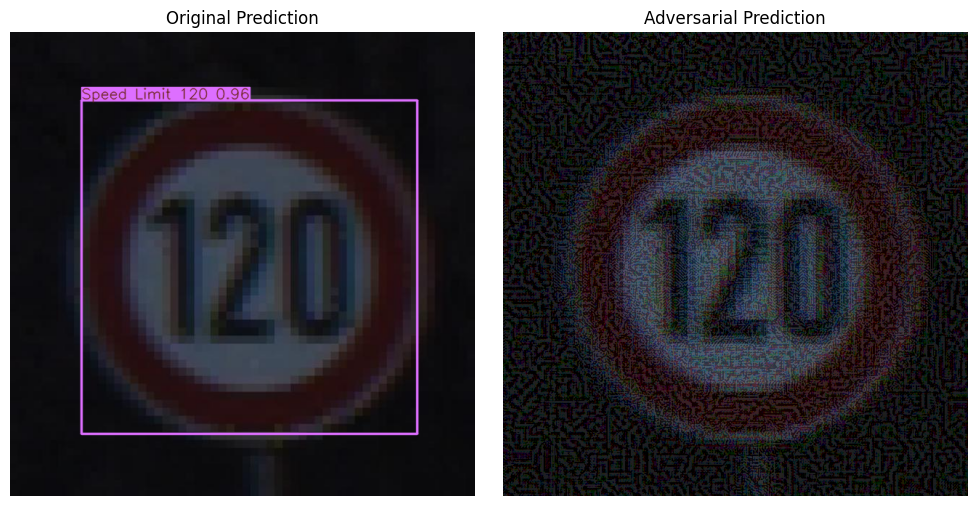

In [21]:
compare_original_and_adversarial_png(model, image_path, adv_image,0.25)

# UAP Attack for Object Detectors

---

## 1. Attack Idea

This implementation adapts a **Universal Adversarial Perturbation (UAP)** approach to fool object detectors (e.g., YOLOv8) across *many images* using a single, shared perturbation \(\delta\). The main points:

1. **Single Perturbation for All Images**: \(\delta\) is learned to degrade model performance for *any* input.  
2. **Feature-Level Disruption**: Exploits the detector’s internal representations to degrade classification and (optionally) localization.  
3. **Bounded Perturbation**: Clamps perturbation to \(\|\delta\|_\infty \le \epsilon\).  
4. **Mini-Batch Training**: Iteratively refines \(\delta\) by processing a set of images.  
5. **Stealth**: Maintains imperceptibility constraints (small \(\epsilon\)) while maximizing the drop in detection accuracy.

---

## 2. Attack Steps & Loss Function

### Key Components of UAP:

1. **Data-Driven**: (optional) We gather a subset of training images or use random proxies (data-independent).  
2. **Iterative Refinement**: Unlike FGSM’s single-step approach, we typically run multiple epochs.  
3. **Universal Across Images**: We accumulate gradients from *all* images and update the same \(\delta\).

### Mathematical Formulation

**Loss Function** (simplified):

\[
\mathcal{L}(\delta) \;=\; \sum_{x \in \mathcal{D}} \big(\; \mathcal{L}_{\mathrm{detect}}(x + \delta) \;+\; \lambda \|\delta\|_2 \big)
\]

Where:
- \(\mathcal{D}\) is the training set (or a chosen subset).  
- \(\mathcal{L}_{\mathrm{detect}}(\cdot)\) is the detection loss (e.g., cross-entropy on classification logits).  
- \(\|\delta\|_2\) is an optional L2 regularizer for stability (\(\lambda\) is the trade-off).  
- \(\delta\) is clamped in each update step to ensure \(\|\delta\|_\infty \le \epsilon\).

---

## 3. Implementation Overview

### Pipeline:

```python
1. Gather or sample a set of images (final_image_paths).
2. Initialize delta = 0 with shape = (1, C, H, W).
3. For each epoch:
   a. For each image x:
       i. x_adv = x + delta
       ii. raw_outputs = model.model(x_adv)
       iii. Filter out low-confidence detections
       iv. classification_loss = cross_entropy(...)
       v. reg_loss = lambda_reg * torch.norm(delta, p=2)
       vi. total_loss = classification_loss + reg_loss
       vii. total_loss.backward()
       viii. optimizer.step()
       ix. clamp delta to [-epsilon, epsilon]
   b. Print average epoch loss
4. Return final delta
```

### Key Components:

| **Component**         | **Description**                                                   |
|-----------------------|-------------------------------------------------------------------|
| **Training Set**      | Either real images or random “proxy data” (for data-independent). |
| **Iterative Updates** | Each epoch, accumulate gradients from *all* images.              |
| **Confidence Mask**   | Only compute classification loss for bounding boxes above a threshold. |
| **Clamping**          | Keep \(\delta\) within \([- \epsilon, \epsilon]\).               |

---

## 4. Usage Example

```python
from your_uap_code import train_universal_attack
from ultralytics import YOLO

# Prepare your data
images_dir = "/content/train/images"
labels_dir = "/content/train/labels"
final_image_paths = [...]  # e.g. from a stratified sampling script
model_path = "yolov8n.pt"

# Create & load model
model = YOLO(model_path)

# Train universal delta
delta, losses = train_universal_attack(
    model,
    final_image_paths,
    preprocess_image_fn,  # your function that loads & normalizes an image
    device="cuda",
    num_epochs_uap=20,
    lambda_reg=0.01,
    epsilon=0.1,
    conf_threshold=0.2,
    lr=0.1,
    momentum=0.9
)
```

---

## 5. papers

1. **Universal Adversarial Perturbations**  
   - [Moosavi-Dezfooli et al., CVPR 2017](https://arxiv.org/abs/1610.08401)  
   - [Mopuri et al., BMVC 2017](https://arxiv.org/abs/1707.01705)

2. **Attacks on Object Detectors**  
   - [Xie et al., CVPR 2019 (Translation Invariant Attack)](https://arxiv.org/abs/1904.02884)  
   - [Wei et al., AAAI 2022 (Cross-Task Transfer)](https://arxiv.org/abs/2201.08517)

3. **YOLOv8 Documentation**  
   - [Ultralytics YOLOv8 Docs](https://docs.ultralytics.com/)


In [24]:
import torch

delta_1 = torch.load("universal_delta_1_epsilon.pth", map_location=torch.device('cpu'))
delta_08 = torch.load("universal_delta_08_epsilon.pth", map_location=torch.device('cpu'))


Running prediction on original tensor...

0: 640x640 1 Speed Limit 120, 791.0ms
Speed: 0.1ms preprocess, 791.0ms inference, 40.8ms postprocess per image at shape (1, 3, 640, 640)
Running prediction on loaded adversarial tensor...

0: 640x640 (no detections), 470.2ms
Speed: 0.0ms preprocess, 470.2ms inference, 17.8ms postprocess per image at shape (1, 3, 640, 640)


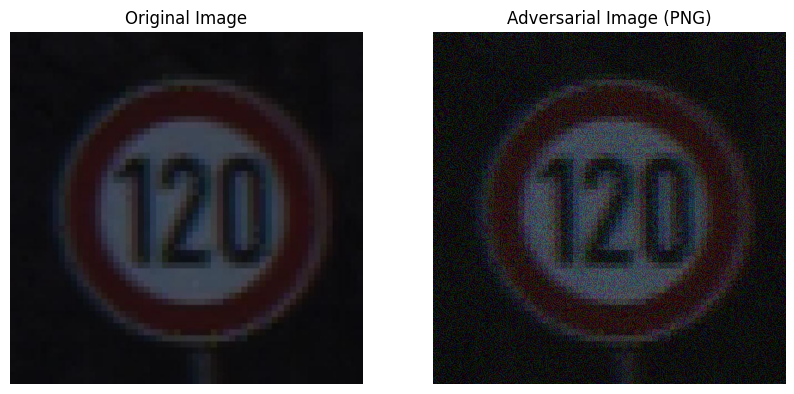

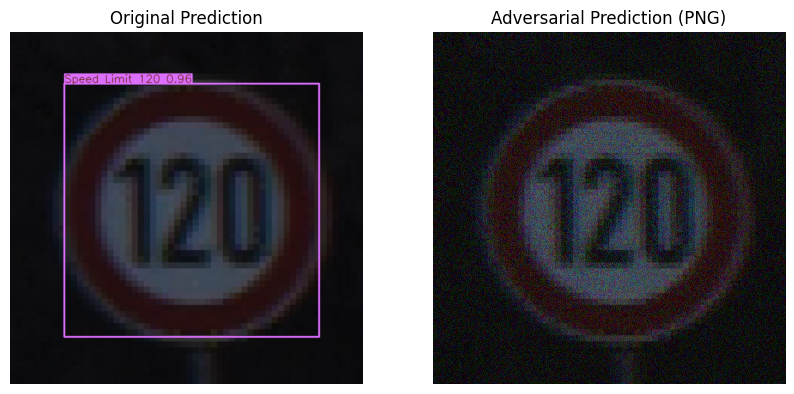

In [26]:
test_image = preprocess_image(image_path)
test_image = test_image.to(device)
adv = test_image+delta_1
compare_original_and_adversarial_png(model,image_path,adv,0.5)

Running prediction on original tensor...



0: 640x640 1 Speed Limit 120, 787.6ms
Speed: 0.1ms preprocess, 787.6ms inference, 4.7ms postprocess per image at shape (1, 3, 640, 640)
Running prediction on loaded adversarial tensor...

0: 640x640 (no detections), 380.0ms
Speed: 0.0ms preprocess, 380.0ms inference, 15.0ms postprocess per image at shape (1, 3, 640, 640)


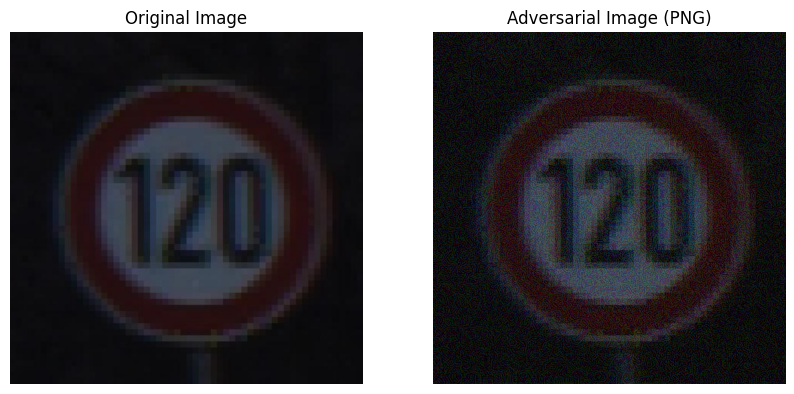

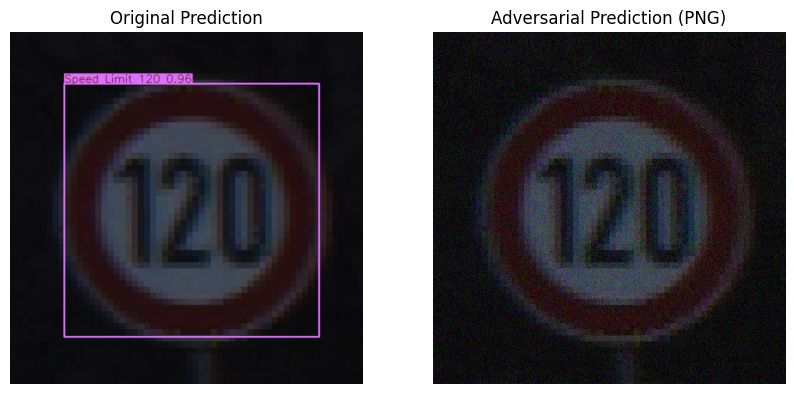

In [28]:
test_image = preprocess_image(image_path)
test_image = test_image.to(device)
adv2= test_image+delta_08
compare_original_and_adversarial_png(model,image_path,adv2,0.5)

# PGD Attack for Object Detectors

---

## 1. Attack Idea
This implementation adapts the **Projected Gradient Descent (PGD)** attack for object detection models (YOLOv8). The attack:
1. **Targets High-Confidence Detections**: Focuses on predictions with confidence above a specified threshold.
2. **Maximizes Classification Error**: Iteratively perturbs the image to confuse class predictions.
3. **Optional Bounding Box Disruption**: Can degrade localization accuracy (disabled by default).
4. **Maintains Stealth**: Uses L-infinity bounded perturbations (ε typically 0.01–0.1) to ensure visual similarity.
5. **Iterative Strength**: Applies multiple smaller steps with projection, making it stronger than single-step attacks like FGSM.

---

## 2. Attack Steps & Loss Function

### Key Components from PGD Paper:
1. **Iterative Gradient Descent**: Computes gradients over multiple steps, refining perturbations for stronger attacks.
2. **Projection**: Ensures perturbations stay within an L∞ ε-ball, balancing attack strength and stealth.
3. **Random Initialization**: Optionally starts with random noise to escape local optima and enhance effectiveness.

### Mathematical Formulation:
**Total Loss**:
$$
\mathcal{L}_{\text{total}} = -\sum_{i \in \mathcal{D}} \log(p(y_i|\mathbf{x}_{\text{adv}}))
$$

**Perturbation Update** (per iteration):
$$
\mathbf{x}_{\text{adv}}^{t+1} = \Pi_{\|\mathbf{x}_{\text{adv}} - \mathbf{x}_{\text{orig}}\|_\infty \leq \epsilon} \left( \mathbf{x}_{\text{adv}}^t + \alpha \cdot \text{sign}(\nabla_{\mathbf{x}} \mathcal{L}(\mathbf{x}_{\text{adv}}^t, y)) \right)
$$

Where:
- $\mathcal{D}$ = High-confidence detections.
- $p(y_i|\mathbf{x}_{\text{adv}})$ = Class probability for detection $i$ in the adversarial image.
- $\epsilon$ = Maximum L∞ perturbation magnitude.
- $\alpha$ = Step size per iteration.
- $\Pi$ = Projection operator clipping to the ε-ball around the original image.
- Classification loss drives misclassification; L∞ constraint is enforced explicitly via projection.

---

## 3. Implementation Overview

### Pipeline:
```python
1. Load YOLOv8 detection model
2. Preprocess input image (normalization + resizing)
3. Initialize adversarial image (optionally with random noise in ε-ball)
4. For each iteration (num_steps):
   a. Extract raw model outputs (bypass NMS/post-processing)
   b. Calculate combined confidence scores (objectness × class probability)
   c. Filter detections by confidence threshold
   d. Compute classification loss between original and current predictions
   e. Backpropagate loss to get image gradient
   f. Update adversarial image: x_adv = x_adv + α·sign(∇x ℒ)
   g. Project to ε-ball: clip x_adv to [x_orig - ε, x_orig + ε]
   h. Clamp to valid pixel range [0,1]
5. Return final adversarial image
```

### Key Components:
| Component               | Description                                                                 |
|-------------------------|-----------------------------------------------------------------------------|
| **Raw Output Extraction** | Accesses model backbone outputs before non-max suppression                 |
| **Confidence Filtering**  | Combines objectness and class probability for detection quality assessment |
| **Iterative Updates**     | Applies smaller perturbations over multiple steps for stronger attacks     |
| **Projection**            | Clips perturbations to enforce L∞ ε-ball constraint                       |
| **Random Start**          | Optional random noise initialization to improve attack robustness          |
| **Device Agnostic**       | Works on both CPU/GPU with automatic tensor placement                      |

---

## 4. Usage Example

```python
# Generate adversarial example
adv_image = pgd_attack_detector(
    image_path="highway.jpg",
    model_path="yolov8n.pt",
    epsilon=0.05,        # Moderate perturbation budget
    num_steps=7,         # Number of iterations
    step_size=0.005,     # Step size per iteration
    conf_threshold=0.6,  # Target confident detections
    random_start=True,   # Use random initialization
    device="cuda"
)

```

---

## 5. Papers

1. **Original PGD Paper**:  
   [Towards Deep Learning Models Resistant to Adversarial Attacks (Madry et al., 2017)](https://arxiv.org/abs/1706.06083)

2. **Object Detector Attacks**:  
   [Adversarial Examples for Object Detectors (Lu et al., 2017)](https://arxiv.org/abs/1712.08063)


In [32]:
adv_image= pgd_attack_detector(
    image_path= image_path,
    model_path = 'yolov8n_TrafficSigns.pt',
    epsilon=0.1,  # Smaller for training robustness
    num_steps=10,
    step_size=0.025,
    conf_threshold=0.25,
    random_start=True,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

Running prediction on original tensor...

0: 640x640 1 Speed Limit 120, 558.3ms
Speed: 1.5ms preprocess, 558.3ms inference, 52.3ms postprocess per image at shape (1, 3, 640, 640)
Running prediction on loaded adversarial tensor...

0: 640x640 (no detections), 263.3ms
Speed: 0.1ms preprocess, 263.3ms inference, 8.4ms postprocess per image at shape (1, 3, 640, 640)


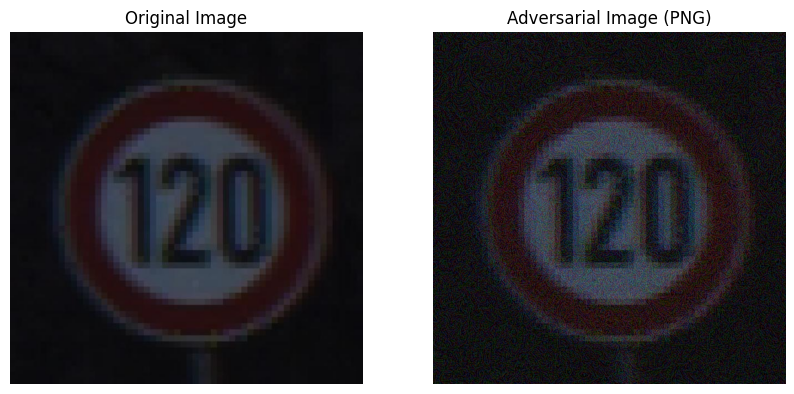

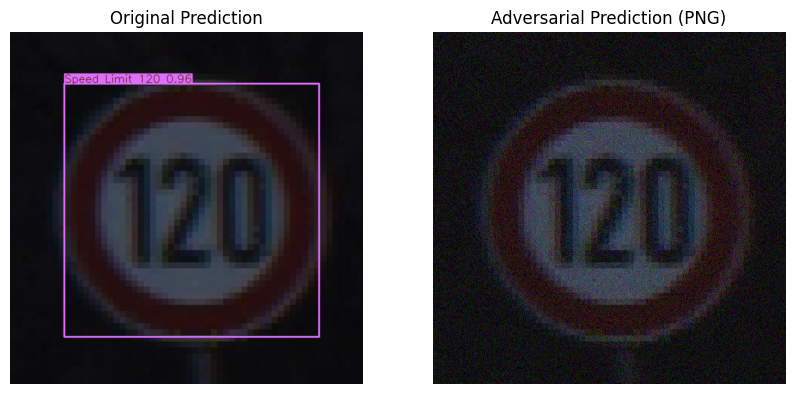

In [33]:
compare_original_and_adversarial_png(model,image_path,adv_image,0.25)

# Square Attack for Object Detectors

---

## 1. Attack Idea
This implementation adapts the **Square Attack**, a black-box adversarial attack, for object detection models (YOLOv8). The attack:
1. **Targets High-Confidence Detections**: Focuses on predictions with confidence above a specified threshold.
2. **Maximizes Classification Error**: Perturbs image patches to confuse class predictions or suppress detections.
3. **Local Perturbations**: Applies random noise to small square patches, unlike global attacks (e.g., FGSM, PGD).
4. **Maintains Stealth**: Uses L-infinity bounded perturbations (ε typically 0.01–0.1) to ensure visual similarity.
5. **Black-Box Efficiency**: Relies solely on model outputs (no gradients), with early stopping when all detections are suppressed.

---

## 2. Attack Steps & Loss Function

### Key Components from Square Attack Paper:
1. **Score-Based Optimization**: Iteratively tests random perturbations, keeping those that worsen model performance.
2. **Patch-Based Strategy**: Perturbs small square regions, exploiting local vulnerabilities in object detectors.
3. **Early Stopping**: Terminates when no detections remain above the confidence threshold, optimizing computational efficiency.

### Mathematical Formulation:
**Total Loss**:
$$
\mathcal{L}_{\text{total}} = -\sum_{i \in \mathcal{D}} \log(p(y_i|\mathbf{x}_{\text{adv}})) + \lambda \sum_{i \in \mathcal{D}} \log(o_i)
$$

**Perturbation Update**:
$$
\mathbf{x}_{\text{adv}}^{t+1} = \Pi_{\|\mathbf{x}_{\text{adv}} - \mathbf{x}_{\text{orig}}\|_\infty \leq \epsilon} \left( \mathbf{x}_{\text{adv}}^t + \delta_{\text{patch}} \right)
$$
Where:
- $\mathcal{D}$ = High-confidence detections.
- $p(y_i|\mathbf{x}_{\text{adv}})$ = Class probability for detection $i$ in the adversarial image.
- $o_i$ = Objectness score for detection $i$.
- $\epsilon$ = Maximum L∞ perturbation magnitude.
- $\delta_{\text{patch}}$ = Random perturbation applied to a square patch.
- $\Pi$ = Projection operator clipping to the ε-ball around the original image.
- $\lambda$ = Implicit weight (not explicitly tuned in this implementation).
- Loss encourages misclassification; suppression (no detections) is prioritized via early stopping.

---

## 3. Implementation Overview

### Pipeline:
```python
1. Load YOLOv8 detection model
2. Preprocess input image (normalization + resizing)
3. Evaluate initial detections and loss on clean image
4. For each iteration (up to num_iterations):
   a. Select random square patch coordinates
   b. Apply random perturbation to patch
   c. Project perturbation to ε-ball
   d. Clamp image to valid pixel range [0,1]
   e. Compute loss on high-confidence detections
   f. Early stop if no detections remain above threshold
   g. Keep perturbation if loss increases (worse performance)
5. Return final adversarial image
```

### Key Components:
| Component               | Description                                                                 |
|-------------------------|-----------------------------------------------------------------------------|
| **Raw Output Extraction** | Accesses model backbone outputs before non-max suppression                 |
| **Confidence Filtering**  | Combines objectness and class probability for detection quality assessment |
| **Patch Perturbations**   | Applies random noise to small square regions, testing local vulnerabilities |
| **Projection**            | Clips perturbations to enforce L∞ ε-ball constraint                       |
| **Early Stopping**        | Halts when no detections exceed confidence threshold                     |
| **Device Agnostic**       | Works on both CPU/GPU with automatic tensor placement                      |

---

## 4. Usage Example

```python
# Generate adversarial example
adv_image = square_attack_detector(
    image_path="highway.jpg",
    model_path="yolov8n.pt",
    epsilon=0.05,        # Moderate perturbation budget
    patch_size=16,       # Size of square patches
    num_iterations=500,  # Maximum iterations
    conf_threshold=0.6,  # Target confident detections
    device="cuda"
)

```

---

## 5. Papers

1. **Original Square Attack Paper**:  
   [Square Attack: A Query-Efficient Black-Box Adversarial Attack via Random Search (Andriushchenko et al., 2020)](https://arxiv.org/abs/1912.07133)

2. **Object Detector Attacks**:  
   [Adversarial Examples for Object Detectors (Lu et al., 2017)](https://arxiv.org/abs/1712.08063)

3. **YOLOv8 Documentation**:  
   [Ultralytics YOLOv8 Docs](https://docs.ultralytics.com/)


In [4]:
adv_image = square_attack_detector(
    image_path=image_path,
    model_path="yolov8n_TrafficSigns.pt",
    epsilon=0.1,
    patch_size=256,
    num_iterations=500,
    conf_threshold=0.3,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

Iteration 0/500 — best loss: 0.0005
Iteration 50/500 — best loss: 1.7059
Early stopping at iteration 56: all detections < 0.3


Running prediction on original tensor...



0: 640x640 1 Speed Limit 120, 713.3ms
Speed: 0.0ms preprocess, 713.3ms inference, 8.2ms postprocess per image at shape (1, 3, 640, 640)
Running prediction on loaded adversarial tensor...

0: 640x640 (no detections), 286.2ms
Speed: 0.0ms preprocess, 286.2ms inference, 8.4ms postprocess per image at shape (1, 3, 640, 640)


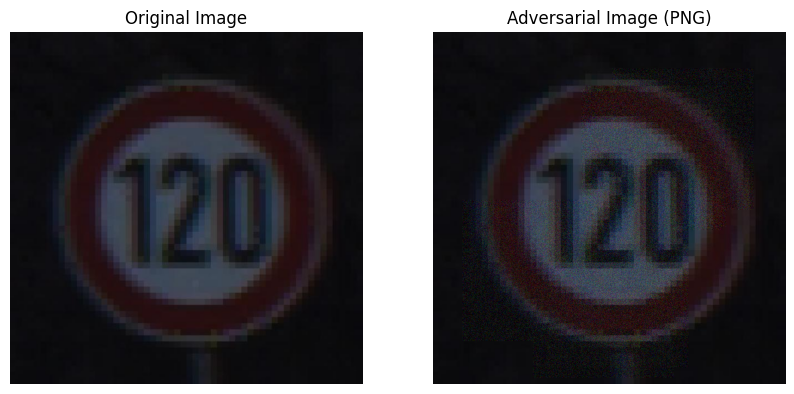

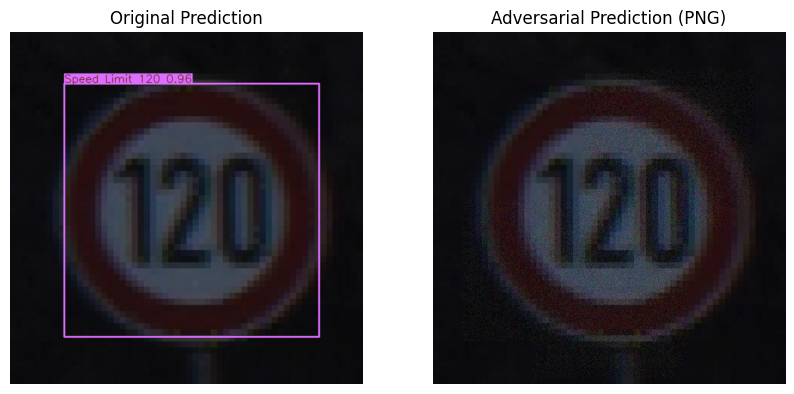

In [5]:
compare_original_and_adversarial_png(model,image_path,adv_image,0.3)

# HopSkipJump Attack for Object Detectors
## 1. Attack Idea
This implementation adapts the HopSkipJump attack, a black-box adversarial attack, for object detection models (YOLOv8). The attack:

Targets High-Confidence Detections: Focuses on misleading the model's predictions for detected objects.
Minimizes Perturbation: Iteratively refines the adversarial example to reduce the distance from the original image while maintaining misclassification.
Query-Based Optimization: Uses model queries to estimate gradients and refine perturbations without needing model internals.
Supports L2 and L∞ Norms: Allows flexibility in the type of perturbation applied.

## 2. Attack Steps & Loss Function
Key Components from HopSkipJump Paper:

Initialization: Starts with a large perturbation to quickly find an adversarial example.
Gradient Estimation: Uses finite differences to approximate the gradient direction.
Geometric Step Search: Moves the adversarial example away from the decision boundary.
Binary Search Projection: Finds a point closer to the original image while remaining adversarial.

Mathematical Formulation:
The attack aims to minimize the distance ( d(x_{\text{adv}}, x_{\text{orig}}) ) subject to the constraint that the model misclassifies ( x_{\text{adv}} ). The distance metric ( d ) can be L2 or L∞ norm.
## 3. Implementation Overview
Pipeline:
1. Initialize adversarial example with large perturbation
2. For each iteration:
   a. Estimate gradient direction using finite differences
   b. Perform geometric step search to move away from decision boundary
   c. Use binary search to project closer to original image
   d. Update best adversarial example if improved
3. Return the best adversarial example found



## 4. Usage Example
```python
x_orig = preprocess_image(image_path)
adv = hop_skip_jump_attack(model, x_orig, epsilon=0.1, delta=0.1, batch_size=100, norm="l2", max_queries=30, max_iters=10)
```

## 1. Papers

Original HopSkipJump Paper:HopSkipJumpAttack: A Query-Efficient Decision-Based Attack (Chen et al., 2019)

Object Detector Attacks:Adversarial Examples for Object Detectors (Lu et al., 2017)

YOLOv8 Documentation:Ultralytics YOLOv8 Docs




In [5]:
image_path = "../120.jpg"
x_orig = preprocess_image(image_path)
adv = hop_skip_jump_attack(model, x_orig, epsilon=0.1, delta=0.1, batch_size=100, norm="l2", max_queries=30, max_iters=10)

0: 640x640 1 Speed Limit 120, 408.6ms
Speed: 0.1ms preprocess, 408.6ms inference, 20.8ms postprocess per image at shape (1, 3, 640, 640)
Starting attack (original label: 5.0, confidence: 0.9632)

0: 640x640 1 Speed Limit 120, 274.3ms
Speed: 0.0ms preprocess, 274.3ms inference, 6.4ms postprocess per image at shape (1, 3, 640, 640)
Original label: 5.0, confidence: 0.9632

0: 640x640 (no detections), 215.7ms
Speed: 0.3ms preprocess, 215.7ms inference, 4.0ms postprocess per image at shape (1, 3, 640, 640)
Found initial adversarial example (attempt 1):
  Adversarial label: -1, confidence: 0.0000
  Initial distance: 108.3900

0: 640x640 (no detections), 267.5ms
Speed: 0.0ms preprocess, 267.5ms inference, 4.2ms postprocess per image at shape (1, 3, 640, 640)
Initial distance: 108.3900

Iteration 1, current distance: 108.3900, queries: 22/30

0: 640x640 (no detections), 179.2ms
Speed: 0.0ms preprocess, 179.2ms inference, 4.3ms postprocess per image at shape (1, 3, 640, 640)
Estimating gradient

Running prediction on original tensor...

0: 640x640 1 Speed Limit 120, 547.1ms
Speed: 0.0ms preprocess, 547.1ms inference, 17.3ms postprocess per image at shape (1, 3, 640, 640)
Running prediction on loaded adversarial tensor...

0: 640x640 (no detections), 217.1ms
Speed: 0.0ms preprocess, 217.1ms inference, 5.6ms postprocess per image at shape (1, 3, 640, 640)


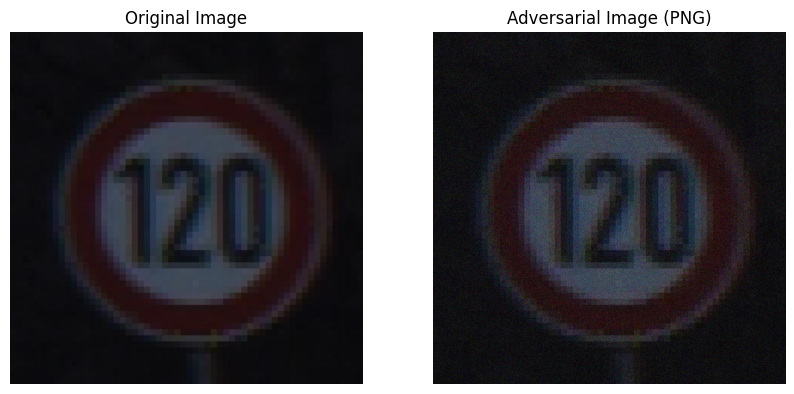

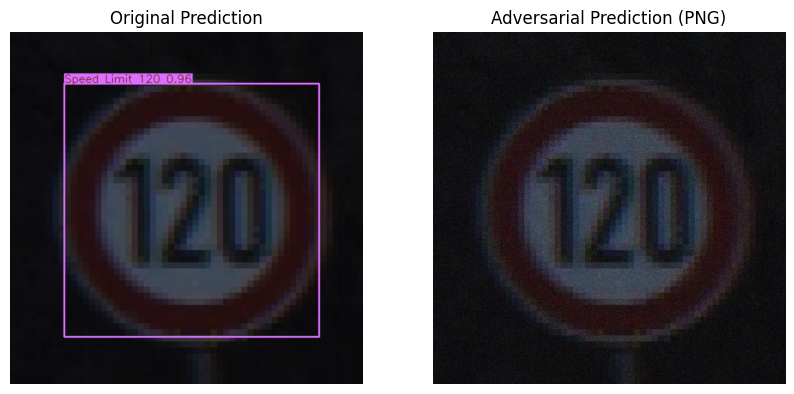

In [6]:
compare_original_and_adversarial_png(model,image_path,adv,0.3)